# Bagging et Random Forest : construire une forêt aléatoire à la main

Un arbre de décision profond est un modèle instable. Ré-entraînez-le sur un échantillon légèrement différent et vous obtenez un arbre différent, donc des prédictions différentes. Cette instabilité porte un nom : la **variance**. Elle explique l'écart classique entre 100 % d'accuracy à l'entraînement et une performance médiocre en test.

Le bagging répond à ce problème sans contraindre l'arbre : on en entraîne plusieurs sur des versions tirées au sort du jeu de données, puis on moyenne leurs prédictions. La Random Forest ajoute un ingrédient qui change tout, et que ce notebook mesure explicitement.

**Ce que ce notebook construit**

1. Le mécanisme complet déroulé à la main sur six clients, chaque valeur intermédiaire affichée.
2. Une Random Forest écrite en numpy pur — arbre, recherche de split par sommes cumulées, bootstrap, score out-of-bag — puis confrontée à `scikit-learn`.
3. Une mesure directe de ce que l'agrégation fait au **biais** et à la **variance**, sur 60 jeux d'entraînement indépendants.
4. L'effet chiffré de `n_estimators` et `max_features`, et le piège de l'importance des variables par défaut.

**Pourquoi réimplémenter ce qui existe déjà.** `RandomForestClassifier` tient en une ligne. Mais deux points décisifs restent invisibles depuis l'extérieur : ce que contient exactement un échantillon bootstrap, et pourquoi une forêt tire des variables au hasard à chaque nœud alors que le bagging simple ne le fait pas. Les écrire en numpy rend ces deux mécanismes manipulables, et permet de les mesurer plutôt que de les croire.

**Public et prérequis.** Il faut savoir lire du Python et connaître les bases de la classification supervisée. Le fonctionnement d'un arbre de décision est rappelé au fil du texte, mais l'avoir déjà croisé aide.

**Cas d'usage.** Prédiction de résiliation (*churn*) chez un opérateur télécom : identifier, parmi les clients actifs, ceux qui risquent de partir dans les trois mois.

**Reproductibilité.** Python 3.12, numpy 2.4, scikit-learn 1.8, pandas 3.0, matplotlib 3.10. Toutes les graines sont fixées ; le notebook s'exécute de bout en bout en moins d'une minute et ne nécessite aucun fichier externe.

## 1. Les données

Le jeu est simulé plutôt qu'importé, pour une raison pratique : il doit être reproductible chez n'importe quel lecteur sans téléchargement. Les paramètres sont calibrés sur ce qu'on observe couramment en télécom — un taux de résiliation autour de 25 %, quelques variables réellement prédictives noyées dans d'autres qui le sont moins, et 3 % d'étiquettes bruitées pour représenter les départs imprévisibles.

Les huit variables décrivent un client actif au moment du scoring.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

GRAINE = 42
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

VARIABLES = [
    "anciennete_mois",       # nombre de mois depuis la souscription
    "nb_reclamations",       # reclamations ouvertes sur les 12 derniers mois
    "conso_data_go",         # consommation data mensuelle moyenne, en Go
    "montant_facture",       # facture mensuelle moyenne, en euros
    "nb_appels_support",     # appels au service client sur 12 mois
    "anciennete_terminal",   # age du telephone, en mois
    "remise_en_cours",       # montant de la remise commerciale active
    "nb_services",           # nombre d'options souscrites
]


def charger_churn(n_clients=4000, graine=GRAINE):
    """Genere un jeu de churn telecom reproductible.

    Args:
        n_clients: nombre de clients a generer.
        graine: graine du generateur, pour la reproductibilite.

    Returns:
        Un couple (X, y) : matrice des variables et vecteur cible binaire
        (1 = le client a resilie).
    """
    X, y = make_classification(
        n_samples=n_clients,
        n_features=len(VARIABLES),
        n_informative=4,
        n_redundant=2,
        n_clusters_per_class=3,
        class_sep=0.9,
        flip_y=0.03,
        weights=[0.75, 0.25],
        random_state=graine,
    )
    return X, y


X, y = charger_churn()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=GRAINE
)

print(f"Clients          : {X.shape[0]}")
print(f"Variables        : {X.shape[1]}")
print(f"Taux de churn    : {y.mean():.1%}")
print(f"Entrainement/test: {len(y_train)} / {len(y_test)}")

pd.DataFrame(X_train[:5], columns=VARIABLES).round(2)

Clients          : 4000
Variables        : 8
Taux de churn    : 25.8%
Entrainement/test: 3000 / 1000


,anciennete_mois,nb_reclamations,conso_data_go,montant_facture,nb_appels_support,anciennete_terminal,remise_en_cours,nb_services
0,1.31,1.24,0.57,-2.74,-1.33,-0.37,1.97,1.19
1,-1.01,-0.23,-0.77,-0.86,-2.45,0.86,-0.56,-1.12
2,0.14,-1.21,-0.96,0.17,1.35,-1.09,0.71,0.30
3,0.54,1.20,0.10,0.42,0.94,-0.15,0.28,0.72
4,-3.25,1.78,0.14,-0.37,-2.43,-0.61,0.34,-1.35


Les valeurs sont centrées et réduites par le générateur : elles se lisent en écarts à la moyenne plutôt qu'en mois ou en euros. Cela ne change rien à la suite — un arbre ne compare que des ordres de grandeur relatifs et se moque de l'échelle de chaque colonne.

### Le point de départ : un arbre seul

Avant d'agréger quoi que ce soit, il faut voir le problème. Un arbre laissé libre de grandir jusqu'à des feuilles pures est le cas d'école du modèle à forte variance.

In [2]:
arbre_seul = DecisionTreeClassifier(random_state=GRAINE).fit(X_train, y_train)

auc_arbre = roc_auc_score(y_test, arbre_seul.predict_proba(X_test)[:, 1])
print(f"Profondeur atteinte : {arbre_seul.get_depth()}")
print(f"Nombre de feuilles  : {arbre_seul.get_n_leaves()}")
print(f"Accuracy train      : {arbre_seul.score(X_train, y_train):.3f}")
print(f"Accuracy test       : {arbre_seul.score(X_test, y_test):.3f}")
print(f"AUC test            : {auc_arbre:.3f}")

Profondeur atteinte : 17
Nombre de feuilles  : 240
Accuracy train      : 1.000
Accuracy test       : 0.880
AUC test            : 0.838


Accuracy parfaite à l'entraînement, douze points de moins en test : l'arbre a mémorisé son échantillon. C'est ce qu'on va corriger — sans toucher à sa profondeur.

## 2. Le mécanisme sur six clients

Avant d'écrire quoi que ce soit de général, on déroule la construction complète d'une forêt de trois arbres sur six clients. Chaque valeur intermédiaire est affichée. C'est le seul endroit du notebook où l'on peut vérifier les calculs à la main, sur papier.

Deux clients rendent le problème non trivial : C5 est un nouveau client qui reste (encore sous engagement) et C6 un client ancien qui part sans avoir réclamé. Aucune règle simple ne peut donc tout expliquer.

In [3]:
X_mini = np.array(
    [
        [3, 2],    # C1 : 3 mois d'anciennete, 2 reclamations
        [8, 0],    # C2
        [5, 3],    # C3
        [24, 1],   # C4
        [2, 1],    # C5 : nouveau client qui reste
        [18, 1],   # C6 : client ancien qui part
    ],
    dtype=float,
)
y_mini = np.array([1, 0, 1, 0, 0, 1])
NOMS_MINI = ["anciennete", "reclamations"]

pd.DataFrame(
    {"anciennete": X_mini[:, 0].astype(int),
     "reclamations": X_mini[:, 1].astype(int),
     "churn": y_mini},
    index=[f"C{i}" for i in range(1, 7)],
)

,anciennete,reclamations,churn
C1,3,2,1
C2,8,0,0
C3,5,3,1
C4,24,1,0
C5,2,1,0
C6,18,1,1


### L'impureté de Gini

Un arbre choisit ses coupures en minimisant l'**impureté** des groupes qu'il crée. L'impureté de Gini d'un nœud vaut `1 - Σ p_k²`, où `p_k` est la proportion de la classe `k` dans le nœud. Elle vaut 0 quand toutes les observations appartiennent à la même classe, et 0,5 au maximum en binaire, quand le nœud est parfaitement mélangé.

La qualité d'une coupure se mesure par le Gini **pondéré** des deux groupes obtenus, chaque groupe comptant à proportion de sa taille.

In [4]:
def gini(y):
    """Impurete de Gini d'un noeud : 1 - somme des proportions au carre.

    Args:
        y: vecteur d'etiquettes binaires (0/1).

    Returns:
        L'impureté, entre 0 (noeud pur) et 0.5 (noeud parfaitement melange).
    """
    if y.size == 0:
        return 0.0
    proportions = np.bincount(y, minlength=2) / y.size
    return 1.0 - np.sum(proportions ** 2)


print(f"Gini du noeud racine        : {gini(y_mini):.4f}")
print(f"Gini d'un groupe [1, 1, 0]  : {gini(np.array([1, 1, 0])):.4f}")
print(f"Gini d'un groupe pur [1,1,1]: {gini(np.array([1, 1, 1])):.4f}")

Gini du noeud racine        : 0.5000
Gini d'un groupe [1, 1, 0]  : 0.4444
Gini d'un groupe pur [1,1,1]: 0.0000


### Trois arbres, trois règles différentes

On construit maintenant trois arbres de profondeur 1 — une seule décision chacun. Deux sources de hasard interviennent :

- le **bootstrap** : chaque arbre est entraîné sur six clients tirés *avec remise* parmi les six. Certains apparaissent en double ou en triple, d'autres sont absents. Les absents s'appellent les **out-of-bag** (OOB) : ce sont des données de test gratuites pour cet arbre-là.
- le **tirage de variables** : une seule des deux variables est proposée à chaque arbre. C'est la contrainte qui fait la différence entre un bagging simple et une Random Forest.

In [5]:
def meilleur_seuil_sur_variable(X, y, variable):
    """Cherche le seuil qui minimise le Gini pondere, sur une seule variable.

    Les seuils candidats sont les milieux entre deux valeurs consecutives
    distinctes, ce qui est la convention de l'algorithme CART.

    Args:
        X: matrice des variables.
        y: etiquettes binaires.
        variable: indice de colonne a examiner.

    Returns:
        Un couple (gini_pondere, seuil).
    """
    meilleur = (np.inf, None)
    valeurs = np.unique(X[:, variable])
    for basse, haute in zip(valeurs[:-1], valeurs[1:]):
        seuil = (basse + haute) / 2
        gauche, droite = y[X[:, variable] <= seuil], y[X[:, variable] > seuil]
        pondere = (gauche.size * gini(gauche) + droite.size * gini(droite)) / y.size
        if pondere < meilleur[0] - 1e-12:
            meilleur = (pondere, seuil)
    return meilleur


generateur = np.random.default_rng(38)
foret_mini = []

for numero in range(1, 4):
    indices = generateur.integers(0, len(y_mini), size=len(y_mini))   # bootstrap
    variable = int(generateur.integers(0, 2))                         # max_features = 1
    oob = sorted(set(range(len(y_mini))) - set(indices.tolist()))

    X_b, y_b = X_mini[indices], y_mini[indices]
    pondere, seuil = meilleur_seuil_sur_variable(X_b, y_b, variable)

    a_gauche = X_b[:, variable] <= seuil
    # une feuille predit la classe majoritaire des observations qu'elle contient
    feuille_gauche = int(np.bincount(y_b[a_gauche], minlength=2).argmax())
    feuille_droite = int(np.bincount(y_b[~a_gauche], minlength=2).argmax())

    foret_mini.append(
        {"variable": variable, "seuil": seuil,
         "gauche": feuille_gauche, "droite": feuille_droite, "oob": oob}
    )

    print(f"Arbre {numero}")
    print(f"  echantillon bootstrap : {[f'C{int(i) + 1}' for i in indices]}")
    print(f"  clients out-of-bag    : {[f'C{i + 1}' for i in oob]}")
    print(f"  Gini avant coupure    : {gini(y_b):.4f}")
    print(f"  regle retenue         : {NOMS_MINI[variable]} <= {seuil}")
    print(f"  Gini pondere apres    : {pondere:.4f}")
    print(f"  feuilles              : gauche -> {feuille_gauche} | droite -> {feuille_droite}")
    print()

Arbre 1
  echantillon bootstrap : ['C2', 'C3', 'C2', 'C2', 'C3', 'C5']
  clients out-of-bag    : ['C1', 'C4', 'C6']
  Gini avant coupure    : 0.4444
  regle retenue         : anciennete <= 6.5
  Gini pondere apres    : 0.2222
  feuilles              : gauche -> 1 | droite -> 0

Arbre 2
  echantillon bootstrap : ['C4', 'C1', 'C6', 'C1', 'C1', 'C4']
  clients out-of-bag    : ['C2', 'C3', 'C5']
  Gini avant coupure    : 0.4444
  regle retenue         : reclamations <= 1.5
  Gini pondere apres    : 0.2222
  feuilles              : gauche -> 0 | droite -> 1

Arbre 3
  echantillon bootstrap : ['C5', 'C3', 'C6', 'C3', 'C5', 'C3']
  clients out-of-bag    : ['C1', 'C2', 'C4']
  Gini avant coupure    : 0.4444
  regle retenue         : reclamations <= 2.0
  Gini pondere apres    : 0.2222
  feuilles              : gauche -> 0 | droite -> 1



Trois arbres, trois règles. Les arbres 2 et 3 utilisent la même variable mais coupent à des endroits différents — cet écart ne vient que du bootstrap. L'arbre 1, lui, a tiré l'autre variable et raisonne sur une logique entièrement distincte.

C'est cette diversité qui fait tout le travail. Il reste à la mettre à profit.

### Le vote, et la probabilité qui en sort

In [6]:
def predire_souche(souche, observation):
    """Prediction d'un arbre de profondeur 1 pour une observation."""
    a_gauche = observation[souche["variable"]] <= souche["seuil"]
    return souche["gauche"] if a_gauche else souche["droite"]


nouveau_client = np.array([7.0, 2.0])   # 7 mois d'anciennete, 2 reclamations
votes = [predire_souche(souche, nouveau_client) for souche in foret_mini]

for numero, (souche, vote) in enumerate(zip(foret_mini, votes), start=1):
    valeur = nouveau_client[souche["variable"]]
    cote = "gauche" if valeur <= souche["seuil"] else "droite"
    print(f"Arbre {numero} : {NOMS_MINI[souche['variable']]} = {valeur:.0f} "
          f"-> feuille {cote} -> vote {vote}")

print()
print(f"Vote majoritaire      : {int(np.bincount(votes, minlength=2).argmax())}")
print(f"Probabilite de churn  : {np.mean(votes):.3f}")

Arbre 1 : anciennete = 7 -> feuille droite -> vote 0
Arbre 2 : reclamations = 2 -> feuille droite -> vote 1
Arbre 3 : reclamations = 2 -> feuille gauche -> vote 0

Vote majoritaire      : 0
Probabilite de churn  : 0.333


La forêt ne renvoie pas seulement une classe mais une **proportion d'arbres** votant pour le churn. C'est cette probabilité qu'on utilise en pratique : une équipe de rétention ne veut pas une liste binaire, elle veut un classement des clients par risque décroissant pour appeler les 500 premiers.

### Le score out-of-bag

Chaque client a été laissé de côté par au moins un arbre. On peut donc le prédire en ne faisant voter **que les arbres qui ne l'ont jamais vu** — ce qui donne une estimation de la performance en généralisation sans mettre le moindre client de côté.

In [7]:
corrects = 0
lignes = []

for i in range(len(y_mini)):
    votes_oob = [predire_souche(s, X_mini[i]) for s in foret_mini if i in s["oob"]]
    prediction = int(np.bincount(votes_oob, minlength=2).argmax())
    corrects += int(prediction == y_mini[i])
    lignes.append({
        "client": f"C{i + 1}",
        "arbres_oob": len(votes_oob),
        "votes": str(votes_oob),
        "prediction": prediction,
        "verite": int(y_mini[i]),
        "correct": "oui" if prediction == y_mini[i] else "non",
    })

score_oob_mini = corrects / len(y_mini)
votes_complets = [
    int(np.bincount([predire_souche(s, X_mini[i]) for s in foret_mini],
                    minlength=2).argmax())
    for i in range(len(y_mini))
]
accuracy_complete = np.mean(np.array(votes_complets) == y_mini)

print(f"Score OOB (chaque client juge par 1 a 2 arbres) : {corrects}/6 = {score_oob_mini:.3f}")
print(f"Accuracy avec les 3 arbres qui votent           : {accuracy_complete:.3f}")

pd.DataFrame(lignes).set_index("client")

Score OOB (chaque client juge par 1 a 2 arbres) : 4/6 = 0.667
Accuracy avec les 3 arbres qui votent           : 0.833


,arbres_oob,votes,prediction,verite,correct
client,,,,,
C1,2,"[1, 0]",0,1,non
C2,2,"[0, 0]",0,0,oui
C3,1,[1],1,1,oui
C4,2,"[0, 0]",0,0,oui
C5,1,[0],0,0,oui
C6,1,[0],0,1,non


Le score OOB est ici plus bas que l'accuracy de la forêt complète, et c'est attendu : chaque client n'est jugé que par un ou deux arbres au lieu de trois. L'estimation OOB est donc structurellement **pessimiste** — elle mesure une forêt plus petite que celle qu'on utilisera. Sur trois arbres l'écart est énorme ; sur trois cents il devient négligeable, ce que la section 6 vérifie.

## 3. Implémentation from scratch

On passe au cas général. Trois briques, en numpy pur, sans aucune bibliothèque d'apprentissage :

1. la recherche du meilleur split sur un sous-ensemble de variables ;
2. un arbre de décision qui applique cette recherche récursivement ;
3. la forêt, qui gère le bootstrap, l'agrégation et le score OOB.

### Brique 1 — la recherche de split

La version naïve teste chaque seuil en recalculant le Gini des deux groupes de zéro, ce qui coûte O(n²) par variable et par nœud. On utilise plutôt des **sommes cumulées** : une fois la colonne triée, le nombre de positifs à gauche de chaque seuil se lit directement dans un `cumsum`, et tous les seuils sont évalués d'un coup en vectoriel.

Une simplification utile en binaire : `1 - p² - (1-p)²` se réécrit `2p(1-p)`, ce qui évite un `bincount` par seuil.

In [8]:
def meilleur_split(X, y, variables_candidates, min_samples_leaf):
    """Split minimisant le Gini pondere parmi les variables proposees.

    Utilise des sommes cumulees sur la colonne triee : tous les seuils d'une
    variable sont evalues en une seule passe vectorisee.

    Args:
        X: matrice des variables du noeud.
        y: etiquettes binaires du noeud.
        variables_candidates: indices des colonnes autorisees pour ce split.
        min_samples_leaf: nombre minimal d'observations par feuille.

    Returns:
        Un triplet (gini_pondere, variable, seuil). variable vaut None si
        aucun split admissible n'ameliore l'impureté du noeud.
    """
    n = y.size
    meilleur_gini, meilleure_variable, meilleur_seuil = gini(y), None, None

    for variable in variables_candidates:
        ordre = np.argsort(X[:, variable], kind="mergesort")
        valeurs, etiquettes = X[ordre, variable], y[ordre]

        # positifs cumules a gauche de chaque coupure possible
        positifs_gauche = np.cumsum(etiquettes)[:-1]
        taille_gauche = np.arange(1, n)
        taille_droite = n - taille_gauche
        positifs_droite = positifs_gauche[-1] + etiquettes[-1] - positifs_gauche

        p_gauche = positifs_gauche / taille_gauche
        p_droite = positifs_droite / taille_droite
        # Gini binaire : 1 - p^2 - (1-p)^2 = 2 p (1-p)
        gini_pondere = (
            taille_gauche * 2 * p_gauche * (1 - p_gauche)
            + taille_droite * 2 * p_droite * (1 - p_droite)
        ) / n

        # une coupure entre deux valeurs egales n'a pas de sens
        admissible = (
            (valeurs[:-1] != valeurs[1:])
            & (taille_gauche >= min_samples_leaf)
            & (taille_droite >= min_samples_leaf)
        )
        if not admissible.any():
            continue

        indices_ok = np.flatnonzero(admissible)
        i = indices_ok[np.argmin(gini_pondere[indices_ok])]
        if gini_pondere[i] < meilleur_gini - 1e-12:
            meilleur_gini = float(gini_pondere[i])
            meilleure_variable = int(variable)
            meilleur_seuil = (valeurs[i] + valeurs[i + 1]) / 2

    return meilleur_gini, meilleure_variable, meilleur_seuil


# verification : sur les six clients, on doit retrouver la coupure de la section 2
_, variable_trouvee, seuil_trouve = meilleur_split(X_mini, y_mini, [1], min_samples_leaf=1)
print(f"Meilleure coupure sur '{NOMS_MINI[variable_trouvee]}' : seuil {seuil_trouve}")

Meilleure coupure sur 'reclamations' : seuil 1.5


### Brique 2 — l'arbre

L'arbre s'arrête quand le nœud est pur, quand la profondeur maximale est atteinte, ou quand il n'y a plus assez d'observations pour former deux feuilles valides. Chaque nœud stocke la proportion de positifs plutôt qu'une classe : c'est ce qui permet à la forêt de moyenner des probabilités et non des votes durs, ce qui est mesurablement plus stable.

Le tirage de `max_features` variables se fait **à chaque nœud**, pas une fois pour l'arbre entier. C'est un détail d'implémentation qui compte : c'est lui qui décorrèle les arbres en profondeur, pas seulement à la racine.

In [9]:
class ArbreDecision:
    """Arbre de decision binaire (classification), avec tirage de variables par noeud."""

    def __init__(self, max_depth=None, min_samples_leaf=1, max_features=None, rng=None):
        """
        Args:
            max_depth: profondeur maximale ; None pour ne pas contraindre.
            min_samples_leaf: nombre minimal d'observations par feuille.
            max_features: nombre de variables tirees au sort a chaque noeud ;
                None pour toutes les considerer.
            rng: generateur numpy, partage avec la foret pour la reproductibilite.
        """
        self.max_depth = np.inf if max_depth is None else max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.rng = np.random.default_rng() if rng is None else rng

    def fit(self, X, y):
        """Construit l'arbre. Retourne self, pour permettre le chainage."""
        self.racine_ = self._construire(X, y, profondeur=0)
        return self

    def _construire(self, X, y, profondeur):
        """Construit recursivement un noeud et ses descendants."""
        if (profondeur >= self.max_depth
                or y.size < 2 * self.min_samples_leaf
                or gini(y) == 0.0):
            return {"feuille": True, "proba": float(y.mean())}

        n_variables = X.shape[1]
        k = min(self.max_features or n_variables, n_variables)
        candidates = self.rng.choice(n_variables, size=k, replace=False)

        _, variable, seuil = meilleur_split(X, y, candidates, self.min_samples_leaf)
        if variable is None:   # aucune des variables tirees ne permet de progresser
            return {"feuille": True, "proba": float(y.mean())}

        a_gauche = X[:, variable] <= seuil
        return {
            "feuille": False,
            "variable": variable,
            "seuil": seuil,
            "gauche": self._construire(X[a_gauche], y[a_gauche], profondeur + 1),
            "droite": self._construire(X[~a_gauche], y[~a_gauche], profondeur + 1),
        }

    def predict_proba(self, X):
        """Probabilite de la classe 1 pour chaque ligne de X."""
        sorties = np.empty(X.shape[0])
        for i, observation in enumerate(X):
            noeud = self.racine_
            while not noeud["feuille"]:
                a_gauche = observation[noeud["variable"]] <= noeud["seuil"]
                noeud = noeud["gauche"] if a_gauche else noeud["droite"]
            sorties[i] = noeud["proba"]
        return sorties

### Brique 3 — la forêt

Le bootstrap se réduit à `rng.integers(0, n, size=n)` : `n` indices tirés au hasard avec remise. Les indices absents de ce tirage sont les out-of-bag de cet arbre.

Le score OOB accumule, pour chaque observation, les probabilités prédites par les seuls arbres qui ne l'ont pas vue, puis compare la moyenne obtenue à la vérité.

In [10]:
class ForetAleatoire:
    """Random Forest pour la classification binaire, en numpy pur."""

    def __init__(self, n_estimators=100, max_features="sqrt", max_depth=None,
                 min_samples_leaf=1, bootstrap=True, random_state=None):
        """
        Args:
            n_estimators: nombre d'arbres agreges.
            max_features: nombre de variables tirees par noeud ; "sqrt" pour
                la racine carree du nombre total, None pour toutes.
            max_depth: profondeur maximale de chaque arbre.
            min_samples_leaf: nombre minimal d'observations par feuille.
            bootstrap: si False, chaque arbre voit le jeu complet et le score
                OOB ne peut pas etre calcule.
            random_state: graine du generateur.
        """
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.bootstrap = bootstrap
        self.random_state = random_state

    def fit(self, X, y):
        """Entraine les arbres et calcule le score OOB si le bootstrap est actif."""
        rng = np.random.default_rng(self.random_state)
        n_obs, n_variables = X.shape
        if self.max_features == "sqrt":
            k = int(np.sqrt(n_variables))
        else:
            k = self.max_features or n_variables

        self.arbres_, self.masques_oob_ = [], []
        for _ in range(self.n_estimators):
            if self.bootstrap:
                indices = rng.integers(0, n_obs, size=n_obs)
            else:
                indices = np.arange(n_obs)
            masque_oob = np.ones(n_obs, dtype=bool)
            masque_oob[indices] = False

            arbre = ArbreDecision(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=k,
                rng=rng,
            ).fit(X[indices], y[indices])

            self.arbres_.append(arbre)
            self.masques_oob_.append(masque_oob)

        self.oob_score_ = self._calculer_score_oob(X, y) if self.bootstrap else None
        return self

    def _calculer_score_oob(self, X, y):
        """Accuracy obtenue en ne faisant voter, pour chaque observation,
        que les arbres qui ne l'ont pas vue a l'entrainement."""
        cumul = np.zeros(len(y))
        compteur = np.zeros(len(y))
        for arbre, masque in zip(self.arbres_, self.masques_oob_):
            if masque.any():
                cumul[masque] += arbre.predict_proba(X[masque])
                compteur[masque] += 1
        jamais_oob = compteur == 0
        if jamais_oob.any():   # possible seulement avec tres peu d'arbres
            cumul, compteur = cumul[~jamais_oob], compteur[~jamais_oob]
            y = y[~jamais_oob]
        return accuracy_score(y, (cumul / compteur >= 0.5).astype(int))

    def predict_proba(self, X):
        """Moyenne des probabilites predites par les arbres."""
        return np.mean([arbre.predict_proba(X) for arbre in self.arbres_], axis=0)

    def predict(self, X):
        """Classe predite, au seuil de 0.5."""
        return (self.predict_proba(X) >= 0.5).astype(int)

## 4. Validation contre scikit-learn

Deux forêts, mêmes données, mêmes réglages : 100 arbres, `max_features="sqrt"`, arbres non contraints. Les implémentations diffèrent sur des détails (gestion des ex æquo, ordre des tirages aléatoires), donc on n'attend pas une égalité au bit près — on attend un accord fort sur les probabilités prédites et sur les métriques.

In [11]:
foret_maison = ForetAleatoire(
    n_estimators=100, max_features="sqrt", random_state=GRAINE
).fit(X_train, y_train)

foret_sklearn = RandomForestClassifier(
    n_estimators=100, max_features="sqrt", oob_score=True,
    random_state=GRAINE, n_jobs=-1
).fit(X_train, y_train)

proba_maison = foret_maison.predict_proba(X_test)
proba_sklearn = foret_sklearn.predict_proba(X_test)[:, 1]

comparaison = pd.DataFrame(
    {
        "from scratch": [
            accuracy_score(y_test, foret_maison.predict(X_test)),
            roc_auc_score(y_test, proba_maison),
            foret_maison.oob_score_,
        ],
        "scikit-learn": [
            foret_sklearn.score(X_test, y_test),
            roc_auc_score(y_test, proba_sklearn),
            foret_sklearn.oob_score_,
        ],
    },
    index=["accuracy test", "AUC test", "score OOB"],
).round(4)

print(f"Correlation des probabilites predites : "
      f"{np.corrcoef(proba_maison, proba_sklearn)[0, 1]:.4f}")
print(f"Ecart absolu moyen                    : "
      f"{np.abs(proba_maison - proba_sklearn).mean():.4f}")
print(f"Accord sur la classe predite          : "
      f"{(foret_maison.predict(X_test) == foret_sklearn.predict(X_test)).mean():.4f}")
print()
comparaison

Correlation des probabilites predites : 0.9910
Ecart absolu moyen                    : 0.0299
Accord sur la classe predite          : 0.9820



,from scratch,scikit-learn
accuracy test,0.9300,0.9160
AUC test,0.9578,0.9579
score OOB,0.9170,0.9160


Les deux implémentations sont d'accord sur plus de 98 % des clients et leurs AUC se tiennent à quelques dix-millièmes. Le mécanisme écrit à la main est donc bien celui que `scikit-learn` exécute — la suite du notebook peut utiliser la version optimisée sans rien perdre du raisonnement.

Un chiffre mérite déjà d'être noté : le score OOB, calculé sans qu'aucun client ne soit mis de côté, tombe à quelques millièmes de l'accuracy mesurée sur le jeu de test.

## 5. Ce que l'agrégation change réellement

L'argument standard est que « moyenner réduit la variance ». C'est vérifiable directement, et c'est le calcul le plus instructif de ce notebook.

Le protocole : on tire 60 jeux d'entraînement **indépendants** de 500 clients chacun, issus du même générateur. Sur chacun, on entraîne un arbre seul et une forêt de 100 arbres, puis on prédit un jeu de test commun. Pour chaque client de test, on obtient donc 60 prédictions par modèle, et on mesure deux choses :

- la **variance** de ces 60 prédictions : à quel point le modèle change de réponse quand on change ses données d'entraînement ;
- l'écart entre la **prédiction moyenne** et la vérité, qui approche le carré du biais : l'erreur systématique qui reste même en moyennant sur tous les jeux possibles.

La théorie prédit un résultat précis et asymétrique : la variance doit chuter, le biais doit rester inchangé.

In [12]:
N_REPETITIONS = 60
X_eval, y_eval = charger_churn(n_clients=600, graine=999)

predictions_arbre = np.zeros((N_REPETITIONS, len(y_eval)))
predictions_foret = np.zeros((N_REPETITIONS, len(y_eval)))

for repetition in range(N_REPETITIONS):
    X_r, y_r = charger_churn(n_clients=500, graine=1000 + repetition)
    predictions_arbre[repetition] = (
        DecisionTreeClassifier(random_state=0).fit(X_r, y_r).predict_proba(X_eval)[:, 1]
    )
    predictions_foret[repetition] = (
        RandomForestClassifier(n_estimators=100, max_features="sqrt",
                               random_state=0, n_jobs=-1)
        .fit(X_r, y_r).predict_proba(X_eval)[:, 1]
    )

resume = pd.DataFrame(
    {
        "variance des predictions": [
            predictions_arbre.var(axis=0).mean(),
            predictions_foret.var(axis=0).mean(),
        ],
        "ecart quadratique moyen a la verite (proxy biais)": [
            ((predictions_arbre.mean(axis=0) - y_eval) ** 2).mean(),
            ((predictions_foret.mean(axis=0) - y_eval) ** 2).mean(),
        ],
        "erreur quadratique totale": [
            ((predictions_arbre - y_eval) ** 2).mean(),
            ((predictions_foret - y_eval) ** 2).mean(),
        ],
    },
    index=["arbre seul", "foret de 100 arbres"],
).round(4)

facteur = (predictions_arbre.var(axis=0).mean()
           / predictions_foret.var(axis=0).mean())
print(f"Variance divisee par {facteur:.1f}")
resume

Variance divisee par 6.1


,variance des predictions,ecart quadratique moyen a la verite (proxy biais),erreur quadratique totale
arbre seul,0.2369,0.2112,0.4480
foret de 100 arbres,0.0389,0.2086,0.2475


Le résultat est net et il est asymétrique, exactement comme annoncé : la variance est divisée par un facteur important, tandis que le proxy du biais bouge de moins de 1,5 %.

C'est la propriété fondamentale du bagging, et elle a une conséquence directe sur les réglages : **puisque l'agrégation ne corrige aucun biais, il faut minimiser le biais de chaque arbre avant d'agréger**. D'où des arbres profonds, non élagués. Leur forte variance individuelle n'est pas un défaut à corriger, c'est la matière première que la moyenne va lisser.

C'est aussi ce qui oppose le bagging au boosting : ce dernier construit des arbres volontairement peu profonds, parce que sa séquence attaque le biais et n'a pas besoin d'apprenants instables.

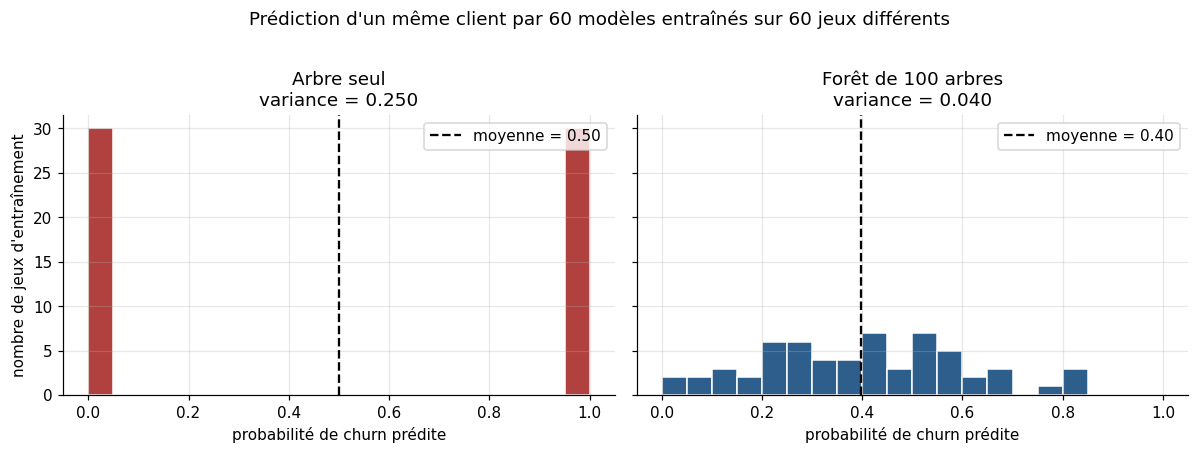

In [13]:
client = int(np.argmax(predictions_arbre.var(axis=0)))   # le client le plus instable

figure, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for axe, predictions, titre, couleur in [
    (axes[0], predictions_arbre, "Arbre seul", "#B0413E"),
    (axes[1], predictions_foret, "Forêt de 100 arbres", "#2E5E8C"),
]:
    axe.hist(predictions[:, client], bins=np.linspace(0, 1, 21),
             color=couleur, edgecolor="white")
    axe.axvline(predictions[:, client].mean(), color="black", linestyle="--",
                label=f"moyenne = {predictions[:, client].mean():.2f}")
    axe.set_title(f"{titre}\nvariance = {predictions[:, client].var():.3f}")
    axe.set_xlabel("probabilité de churn prédite")
    axe.legend()

axes[0].set_ylabel("nombre de jeux d'entraînement")
figure.suptitle(
    f"Prédiction d'un même client par 60 modèles entraînés sur 60 jeux différents",
    y=1.02,
)
plt.tight_layout()
plt.show()

Pour ce client, l'arbre seul hésite sur toute la plage : selon les 500 clients qu'il a vus à l'entraînement, il annonce une probabilité de churn proche de 0 ou proche de 1. Ce n'est pas une nuance, c'est une décision opposée.

La forêt, elle, se concentre autour d'une valeur — et cette valeur est **la même moyenne** que celle de l'arbre seul. On voit sur une seule figure les deux résultats de la section : la dispersion s'effondre, le centre ne bouge pas.

## 6. Application au churn

Retour au jeu complet et aux questions qu'une équipe se pose réellement : le modèle est-il utilisable, sur quel volume de clients, et sur quoi s'appuie-t-il ?

L'accuracy seule ne dit rien d'utile ici — avec 26 % de churn, prédire « personne ne part » donne déjà 74 %. On regarde donc l'AUC, la précision et le rappel sur la classe qui intéresse.

In [14]:
foret = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", oob_score=True,
    random_state=GRAINE, n_jobs=-1
).fit(X_train, y_train)

proba_churn = foret.predict_proba(X_test)[:, 1]
predictions = foret.predict(X_test)

print(f"Score OOB (sans jeu de test)  : {foret.oob_score_:.3f}")
print(f"Accuracy test                 : {foret.score(X_test, y_test):.3f}")
print(f"AUC test                      : {roc_auc_score(y_test, proba_churn):.3f}")
print(f"AUC de l'arbre seul (rappel)  : {auc_arbre:.3f}")
print()
print(classification_report(y_test, predictions,
                            target_names=["reste", "resilie"], digits=3))

matrice = confusion_matrix(y_test, predictions)
pd.DataFrame(matrice,
             index=["reel : reste", "reel : resilie"],
             columns=["predit : reste", "predit : resilie"])

Score OOB (sans jeu de test)  : 0.922
Accuracy test                 : 0.922
AUC test                      : 0.958
AUC de l'arbre seul (rappel)  : 0.838

              precision    recall  f1-score   support

       reste      0.926     0.973     0.949       742
     resilie      0.909     0.775     0.837       258

    accuracy                          0.922      1000
   macro avg      0.917     0.874     0.893      1000
weighted avg      0.921     0.922     0.920      1000



,predit : reste,predit : resilie
reel : reste,722,20
reel : resilie,58,200


Deux lectures à retenir de ce bloc.

D'abord, le score OOB et l'accuracy de test sont pratiquement identiques. L'estimation obtenue sans mettre un seul client de côté vaut celle obtenue sur 1 000 clients réservés. Sur des données rares — cohortes médicales, sinistres graves, défauts de production — c'est une économie considérable en pouvoir statistique.

Ensuite, la lecture métier. Le rappel indique quelle part des résiliations réelles le modèle attrape, la précision quelle part des clients ciblés serait effectivement partie. Ce sont ces deux nombres qui déterminent le budget d'une campagne de rétention, pas l'accuracy. Et comme le modèle renvoie une probabilité, le seuil de 0,5 n'a rien d'obligatoire : l'abaisser attrape plus de résiliations au prix de plus de gestes commerciaux inutiles.

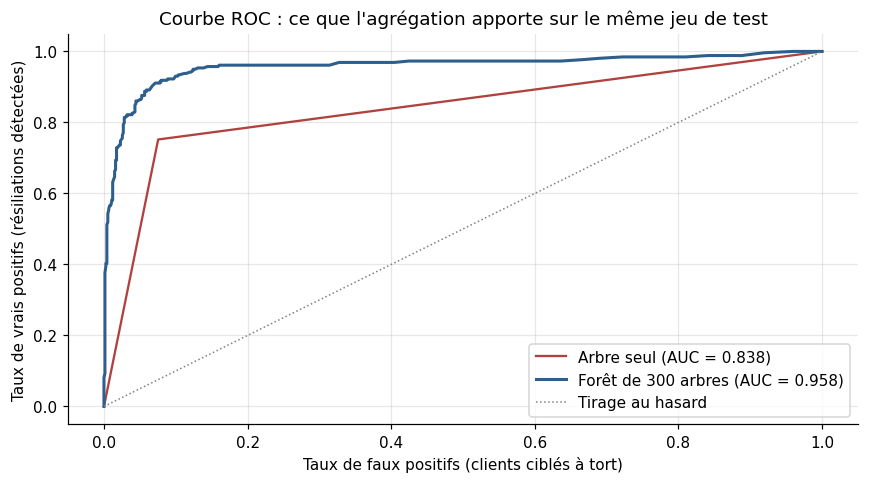

In [15]:
faux_positifs, vrais_positifs, _ = roc_curve(y_test, proba_churn)
fp_arbre, vp_arbre, _ = roc_curve(y_test, arbre_seul.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fp_arbre, vp_arbre, color="#B0413E", linewidth=1.5,
         label=f"Arbre seul (AUC = {auc_arbre:.3f})")
plt.plot(faux_positifs, vrais_positifs, color="#2E5E8C", linewidth=2,
         label=f"Forêt de 300 arbres (AUC = {roc_auc_score(y_test, proba_churn):.3f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1,
         label="Tirage au hasard")
plt.xlabel("Taux de faux positifs (clients ciblés à tort)")
plt.ylabel("Taux de vrais positifs (résiliations détectées)")
plt.title("Courbe ROC : ce que l'agrégation apporte sur le même jeu de test")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

L'écart entre les deux courbes est intégralement dû à l'agrégation. Aucune variable nouvelle, aucune transformation, aucun réglage fin : les mêmes arbres, simplement moyennés.

### Sur quoi le modèle s'appuie-t-il ?

C'est la question que pose toute équipe métier, et c'est là qu'un piège classique se referme.

`feature_importances_` renvoie l'importance dite **MDI** (*mean decrease in impurity*) : la réduction d'impureté totale apportée par chaque variable, cumulée sur tous les nœuds. Elle est gratuite, calculée pendant l'entraînement — et biaisée.

Pour le montrer sans ambiguïté, on ajoute au jeu deux variables **totalement aléatoires**, sans le moindre lien avec la résiliation. Elles ne diffèrent que par leur nombre de valeurs distinctes : une option binaire, et un identifiant client continu.

In [16]:
generateur_bruit = np.random.default_rng(7)
bruit_binaire = generateur_bruit.integers(0, 2, size=len(y)).astype(float)
bruit_continu = generateur_bruit.uniform(0, 1, size=len(y))

X_augmente = np.column_stack([X, bruit_binaire, bruit_continu])
noms_augmentes = VARIABLES + ["option_aleatoire_binaire", "identifiant_aleatoire"]

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_augmente, y, test_size=0.25, stratify=y, random_state=GRAINE
)
foret_augmentee = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", random_state=GRAINE, n_jobs=-1
).fit(Xa_train, ya_train)

permutation = permutation_importance(
    foret_augmentee, Xa_test, ya_test, n_repeats=20,
    random_state=GRAINE, n_jobs=-1,
)

importances = pd.DataFrame(
    {
        "MDI": foret_augmentee.feature_importances_,
        "permutation": permutation.importances_mean,
        "valeurs distinctes": [len(np.unique(X_augmente[:, j]))
                               for j in range(X_augmente.shape[1])],
    },
    index=noms_augmentes,
).sort_values("MDI", ascending=False).round(4)

importances

,MDI,permutation,valeurs distinctes
anciennete_mois,0.1975,0.1397,4000
nb_reclamations,0.1866,0.1440,4000
montant_facture,0.1561,0.1381,4000
nb_appels_support,0.1204,0.0080,4000
anciennete_terminal,0.1165,0.0386,4000
nb_services,0.1028,0.0255,4000
remise_en_cours,0.0404,0.0005,4000
conso_data_go,0.0389,-0.0008,4000
identifiant_aleatoire,0.0356,0.0012,4000
option_aleatoire_binaire,0.0051,0.0000,2


Les deux dernières lignes du classement MDI sont le résultat à retenir. `identifiant_aleatoire` et `option_aleatoire_binaire` sont du bruit pur : leur importance réelle est **exactement nulle**, par construction. Le MDI accorde pourtant à la version continue plusieurs fois l'importance de la version binaire, et la place au niveau de vraies variables du jeu.

L'explication tient au fonctionnement de la recherche de split. Une variable binaire n'offre qu'**un** seuil candidat ; une variable continue à 4 000 valeurs en offre 3 999, et l'algorithme retient le **meilleur** des 3 999. Or le maximum d'un grand nombre de tirages est mécaniquement plus élevé que le maximum d'un seul, même quand tous les tirages sont du bruit. Ces gains fortuits s'accumulent sur des centaines d'arbres.

L'importance par **permutation** ne souffre pas de ce biais : elle ne regarde pas comment le modèle a été construit, mais ce qu'il perd quand on mélange une colonne. Une variable sans information ne fait rien perdre, et ressort à zéro — ce qui est le cas des deux ici.

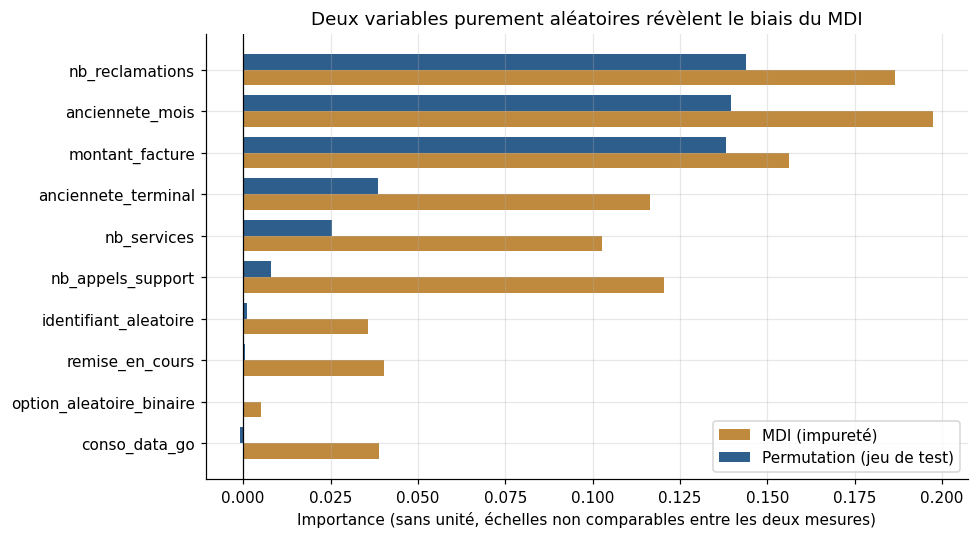

In [17]:
ordre = permutation.importances_mean.argsort()
positions = np.arange(len(ordre))
decalage = 0.38

plt.figure(figsize=(9, 5))
plt.barh(positions - decalage / 2, foret_augmentee.feature_importances_[ordre],
         height=decalage, color="#C08A3E", label="MDI (impureté)")
plt.barh(positions + decalage / 2, permutation.importances_mean[ordre],
         height=decalage, color="#2E5E8C", label="Permutation (jeu de test)")
plt.yticks(positions, [noms_augmentes[i] for i in ordre])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Importance (sans unité, échelles non comparables entre les deux mesures)")
plt.title("Deux variables purement aléatoires révèlent le biais du MDI")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Les échelles des deux mesures ne sont pas comparables entre elles — seul l'**ordre** des variables l'est. Et c'est bien cet ordre qui change : les deux variables de bruit remontent artificiellement dans le classement MDI, l'une nettement plus que l'autre selon sa seule cardinalité.

La règle pratique qui en découle : pour un classement destiné à une équipe métier ou à un régulateur, utiliser la permutation, calculée sur des données que le modèle n'a pas vues. Garder le MDI pour un coup d'œil rapide pendant le développement. Et se méfier des deux quand les variables sont fortement corrélées entre elles : mélanger l'une laisse l'information disponible dans l'autre, et le couple ressort à tort comme négligeable.

## 7. Effet des hyperparamètres

Deux réglages portent l'essentiel du comportement d'une Random Forest. On mesure leur effet plutôt que de le décrire.

### `n_estimators` : le nombre d'arbres

La théorie annonce un plateau. La variance d'une moyenne de `B` prédictions corrélées deux à deux avec un coefficient `ρ` s'écrit `ρσ² + (1-ρ)σ²/B` : le second terme s'annule quand `B` grandit, mais le premier ne bouge pas. Il existe donc un plancher de variance qu'aucun ajout d'arbres ne franchit.

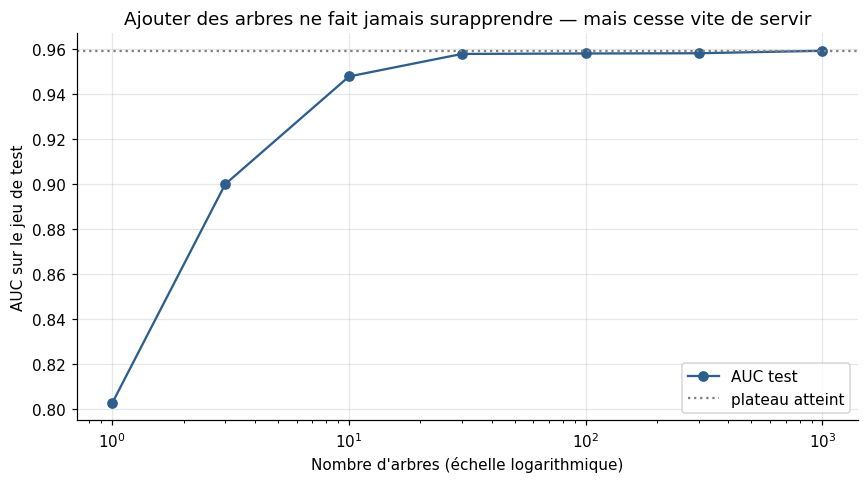

,accuracy test,AUC test
n_estimators,,
1,0.850,0.8028
3,0.876,0.8999
10,0.909,0.9477
30,0.917,0.9577
100,0.916,0.9579
300,0.922,0.9580
1000,0.920,0.9591


In [18]:
nombres_arbres = [1, 3, 10, 30, 100, 300, 1000]
mesures_b = []

for nombre in nombres_arbres:
    modele = RandomForestClassifier(
        n_estimators=nombre, max_features="sqrt", random_state=GRAINE, n_jobs=-1
    ).fit(X_train, y_train)
    mesures_b.append({
        "n_estimators": nombre,
        "accuracy test": modele.score(X_test, y_test),
        "AUC test": roc_auc_score(y_test, modele.predict_proba(X_test)[:, 1]),
    })

resultats_b = pd.DataFrame(mesures_b).set_index("n_estimators").round(4)

plt.figure()
plt.semilogx(resultats_b.index, resultats_b["AUC test"],
             marker="o", color="#2E5E8C", label="AUC test")
plt.axhline(resultats_b["AUC test"].iloc[-1], color="grey", linestyle=":",
            label="plateau atteint")
plt.xlabel("Nombre d'arbres (échelle logarithmique)")
plt.ylabel("AUC sur le jeu de test")
plt.title("Ajouter des arbres ne fait jamais surapprendre — mais cesse vite de servir")
plt.legend()
plt.tight_layout()
plt.show()

resultats_b

L'AUC gagne l'essentiel entre 1 et 30 arbres, puis ne bouge plus que de quelques millièmes jusqu'à 1 000. Aucune dégradation n'apparaît : contrairement à un modèle boosté, une forêt ne surapprend pas quand on lui ajoute des arbres — elle gaspille simplement du calcul.

La règle pratique : quelques centaines d'arbres suffisent presque toujours. Au-delà, on paie de la mémoire et de la latence d'inférence pour un gain qui tient dans le bruit d'échantillonnage.

### `max_features` : le nombre de variables tirées par nœud

C'est le paramètre qui distingue une Random Forest d'un bagging d'arbres, et le seul levier qui agit sur le plancher `ρσ²`. On mesure donc directement `ρ` — la corrélation moyenne entre les probabilités prédites par les arbres d'une même forêt — plutôt que la seule performance.

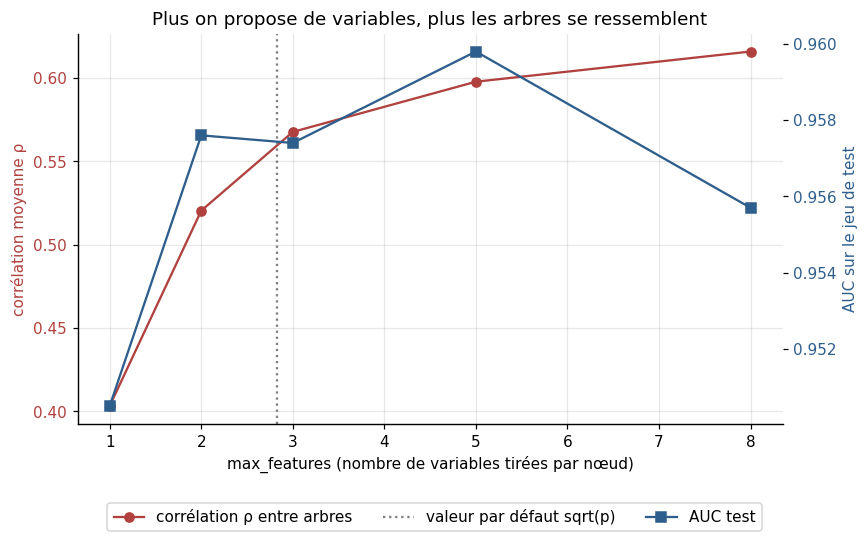

,correlation rho,AUC test,score OOB
max_features,,,
1,0.4033,0.9505,0.9013
2,0.5204,0.9576,0.9197
3,0.5676,0.9574,0.9230
5,0.5977,0.9598,0.9260
8,0.6158,0.9557,0.9273


In [19]:
def correlation_moyenne_entre_arbres(foret, X):
    """Correlation moyenne, hors diagonale, entre les probabilites predites
    par chaque arbre de la foret sur un meme jeu de donnees."""
    probabilites = np.column_stack(
        [arbre.predict_proba(X)[:, 1] for arbre in foret.estimators_]
    )
    matrice_corr = np.corrcoef(probabilites.T)
    nombre = matrice_corr.shape[0]
    return (matrice_corr.sum() - np.trace(matrice_corr)) / (nombre * (nombre - 1))


mesures_mf = []
for nombre_variables in [1, 2, 3, 5, 8]:
    modele = RandomForestClassifier(
        n_estimators=200, max_features=nombre_variables,
        oob_score=True, random_state=GRAINE, n_jobs=-1,
    ).fit(X_train, y_train)
    mesures_mf.append({
        "max_features": nombre_variables,
        "correlation rho": correlation_moyenne_entre_arbres(modele, X_test),
        "AUC test": roc_auc_score(y_test, modele.predict_proba(X_test)[:, 1]),
        "score OOB": modele.oob_score_,
    })

resultats_mf = pd.DataFrame(mesures_mf).set_index("max_features").round(4)

figure, axe_gauche = plt.subplots()
axe_gauche.plot(resultats_mf.index, resultats_mf["correlation rho"],
                marker="o", color="#B0413E", label="corrélation ρ entre arbres")
axe_gauche.set_xlabel("max_features (nombre de variables tirées par nœud)")
axe_gauche.set_ylabel("corrélation moyenne ρ", color="#B0413E")
axe_gauche.tick_params(axis="y", labelcolor="#B0413E")

axe_droite = axe_gauche.twinx()
axe_droite.plot(resultats_mf.index, resultats_mf["AUC test"],
                marker="s", color="#2E5E8C", label="AUC test")
axe_droite.set_ylabel("AUC sur le jeu de test", color="#2E5E8C")
axe_droite.tick_params(axis="y", labelcolor="#2E5E8C")
axe_droite.grid(False)

axe_gauche.axvline(np.sqrt(X_train.shape[1]), color="grey", linestyle=":",
                   label="valeur par défaut sqrt(p)")
figure.legend(loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=3)
plt.title("Plus on propose de variables, plus les arbres se ressemblent")
plt.tight_layout()
plt.show()

resultats_mf

La corrélation monte de façon monotone : plus on propose de variables à chaque nœud, plus les arbres convergent vers les mêmes coupures — et plus le plancher `ρσ²` remonte. C'est le mécanisme que `max_features` sert à combattre.

L'AUC, elle, décrit l'arbitrage complet. Elle est basse à `max_features=1`, où les arbres sont trop contraints pour être bons individuellement — on a échangé trop de biais contre de la décorrélation. Elle forme ensuite un plateau large, où les écarts tiennent dans le bruit. Elle redescend quand toutes les variables sont proposées, c'est-à-dire quand la forêt redevient un simple bagging.

La zone utile est large, ce qui explique que la valeur par défaut `sqrt(p)` convienne sans réglage dans la plupart des projets. À optimiser en priorité quand les variables sont nombreuses et redondantes — un cas où les arbres se corrèlent facilement.

## 8. Ce que cette démonstration établit

- La forêt écrite en numpy pur reproduit `scikit-learn` : plus de 98 % d'accord sur la classe prédite et des AUC séparées de quelques dix-millièmes. Le mécanisme est bien celui décrit, pas une approximation.
- Sur 60 jeux d'entraînement indépendants, l'agrégation divise la variance des prédictions par un facteur important tout en laissant le proxy du biais inchangé à moins de 1,5 %. C'est ce résultat asymétrique qui impose des arbres profonds et non élagués : le biais individuel est le seul terme qu'aucune moyenne ne rattrapera.
- Le score out-of-bag, obtenu sans réserver la moindre observation, tombe à quelques millièmes de l'accuracy mesurée sur un jeu de test de 1 000 clients. Sur données rares, cette validation gratuite vaut d'être utilisée.
- `n_estimators` atteint son plateau autour de quelques dizaines d'arbres. Au-delà, aucun surapprentissage n'apparaît, mais aucun gain non plus — seulement de la mémoire et de la latence.
- `max_features` est le seul réglage qui agit sur la corrélation entre arbres, mesurée ici entre 0,40 et 0,62 selon sa valeur. C'est lui qui sépare une Random Forest d'un bagging ordinaire.
- Deux variables strictement aléatoires suffisent à mettre en défaut l'importance MDI : celle à forte cardinalité obtient plusieurs fois l'importance de sa jumelle binaire, alors que toutes deux valent zéro. L'importance par permutation les ramène l'une et l'autre à zéro.

Trois limites structurelles restent, qu'aucun réglage ne lève : une forêt n'extrapole jamais au-delà de la plage observée à l'entraînement, elle approche une relation lisse par des paliers, et elle n'est pas lisible arbre par arbre — son explication passe nécessairement par des outils *a posteriori*.

## 9. Pour aller plus loin

- Breiman, L. (2001). *Random Forests*. **Machine Learning**, 45(1), 5-32. L'article fondateur ; la section 2 contient l'argument de décorrélation mesuré à la section 7.
- Breiman, L. (1996). *Bagging Predictors*. **Machine Learning**, 24(2), 123-140. L'introduction du bagging et du bootstrap appliqué aux prédicteurs, cinq ans avant les forêts.
- Hastie, T., Tibshirani, R. & Friedman, J. *The Elements of Statistical Learning*, chapitre 15. La décomposition de la variance d'une moyenne de prédicteurs corrélés, et l'analyse détaillée de `max_features`. Disponible gratuitement sur le site de Stanford.
- Strobl, C. et al. (2007). *Bias in random forest variable importance measures*. **BMC Bioinformatics**, 8:25. L'étude de référence sur le biais de cardinalité du MDI, démontré empiriquement à la section 6.
- Documentation scikit-learn, *Permutation feature importance*. Le piège des variables corrélées, avec un exemple reproductible.